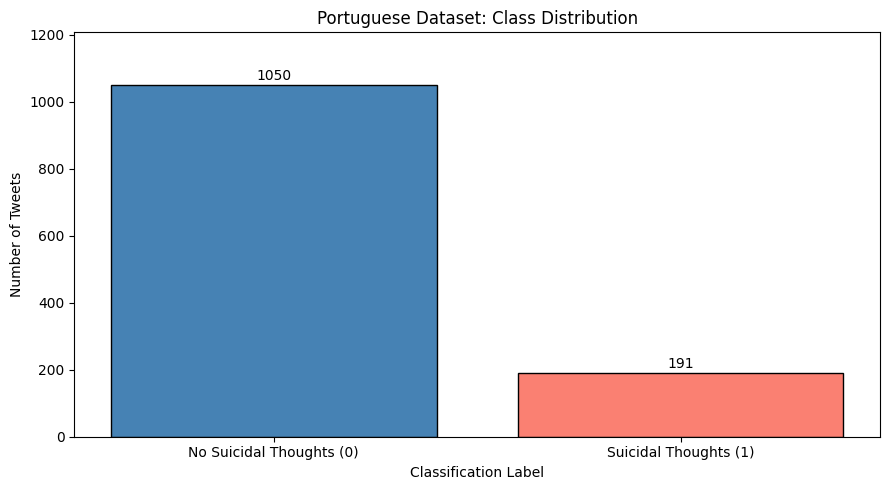

Class Distribution (%):
label
0    84.6
1    15.4
Name: count, dtype: float64


In [7]:

#Visualization 1: Portuguese Class Distribution

import pandas as pd
import matplotlib.pyplot as plt

#Loads the cleaned Portuguese dataset
df = pd.read_csv("portuguese_clean_full.csv")

#Counts the number of tweets in each class
counts = df["label"].value_counts().reindex([0, 1], fill_value=0)

#Sets the figure size
plt.figure(figsize=(9, 5))

#Creates the bar chart and assigns colours to each classification label
bars = plt.bar(
    ["No Suicidal Thoughts (0)", "Suicidal Thoughts (1)"],
    counts.values,
    color=["steelblue", "salmon"],
    edgecolor="black"
)

#Adding labels and a title
plt.title("Portuguese Dataset: Class Distribution")
plt.xlabel("Classification Label")
plt.ylabel("Number of Tweets")

#Displays the number above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        int(bar.get_height()),
        ha="center"
    )

plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()

#Displays the class percentages
print("Class Distribution (%):")
print((counts / counts.sum() * 100).round(1))


**Figure 1: Portuguese Dataset Class Distribution**

Figure 1 shows the distribution of classification labels in the cleaned Brazilian Portuguese dataset. Of the 1,241 tweets, 1,050 (84.6%) are labelled as containing no suicidal thoughts, while 191 (15.4%) are labelled as containing suicidal thoughts. The graph shows a noticeable class imbalance, with the negative category containing considerably more tweets than the positive category. This is similar to the Thai dataset, where tweets or posts without suicidal thoughts also make up the majority. Overall, the Portuguese dataset contains approximately 5.5 times as many negative examples as positive examples.

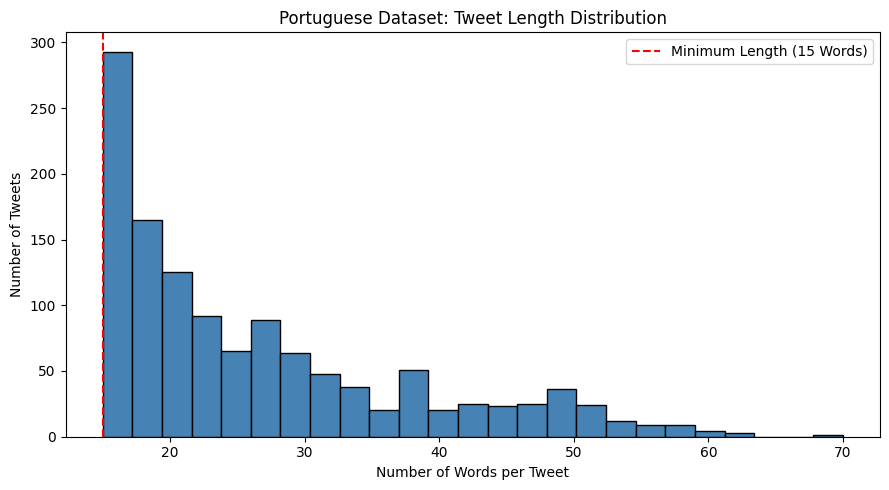

Tweet Length Statistics:
count    1241.000000
mean       26.423852
std        11.321727
min        15.000000
25%        18.000000
50%        22.000000
75%        32.000000
max        70.000000
Name: n_words, dtype: float64


In [8]:

#Visualization 2: Portuguese Tweet Length Distribution

#Sets the figure size of the histogram
plt.figure(figsize=(9, 5))

#Creates the histogram, sets the number of bins, and assigns colours
plt.hist(
    df["n_words"],
    bins=25,
    color="steelblue",
    edgecolor="black"
)

#Shows the minimum word requirement
plt.axvline(
    x=15,
    color="red",
    linestyle="--",
    label="Minimum Length (15 Words)"
)

#Adding labels and a title
plt.title("Portuguese Dataset: Tweet Length Distribution")
plt.xlabel("Number of Words per Tweet")
plt.ylabel("Number of Tweets")

plt.legend()
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Tweet Length Statistics:")
print(df["n_words"].describe())


**Figure 2: Portuguese Tweet Length Distribution**

Figure 2 shows the distribution of tweet lengths in the cleaned Brazilian Portuguese dataset, measured by the number of words per tweet. All 1,241 tweets contain at least 15 words, with an average length of approximately  26.4 words and a median of 22 words. The longest tweet contains 70 words. Since the average is higher than the median, this suggests that some longer tweets increase the overall average. The minimum length requirement was applied to ensure that each tweet contained enough text to be divided into three meaningful sections for the project's text splitting tasks.

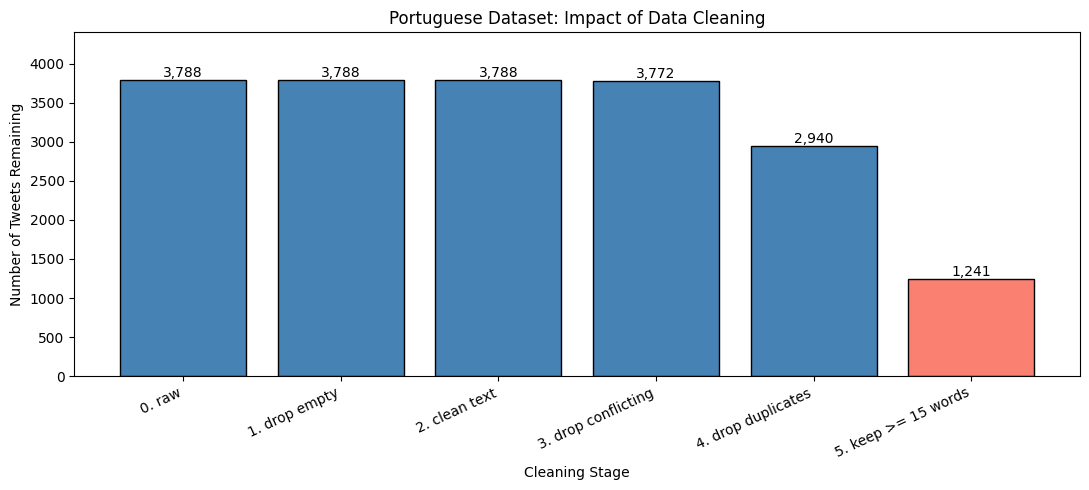

In [9]:

#Visualization 3: Impact of Data Cleaning

#Loads the Portuguese cleaning log
cleaning_df = pd.read_csv("portuguese_cleaning_log.csv")

#Selects the six cleaning stages, excluding the final balanced sample
cleaning_df = cleaning_df.iloc[:6]

#Sets the figure size
plt.figure(figsize=(11, 5))

#Creates the bar chart and assigns colours
bars = plt.bar(
    cleaning_df["step"],
    cleaning_df["rows"],
    color=["steelblue"] * 5 + ["salmon"],
    edgecolor="black"
)

#Adding labels and a title
plt.title("Portuguese Dataset: Impact of Data Cleaning")
plt.xlabel("Cleaning Stage")
plt.ylabel("Number of Tweets Remaining")

#Displays the number above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.xticks(rotation=25, ha="right")
plt.ylim(0, 4400)

plt.tight_layout()
plt.show()


**Figure 3: Impact of Data Cleaning on the Portuguese Dataset**

Figure 3 shows how the number of Portuguese tweets changed throughout the data cleaning process. The original dataset contained 3,788 tweets, which decreased to 2,940 after removing contradictory and duplicate entries. The largest reduction occurred when applying the minimum length requirement of 15 words, leaving 1,241 tweets. Overall, approximately 67.2% of the original dataset was excluded during preprocessing. As a result, only 32.8% of the original tweets remained available for the project's text splitting tasks.

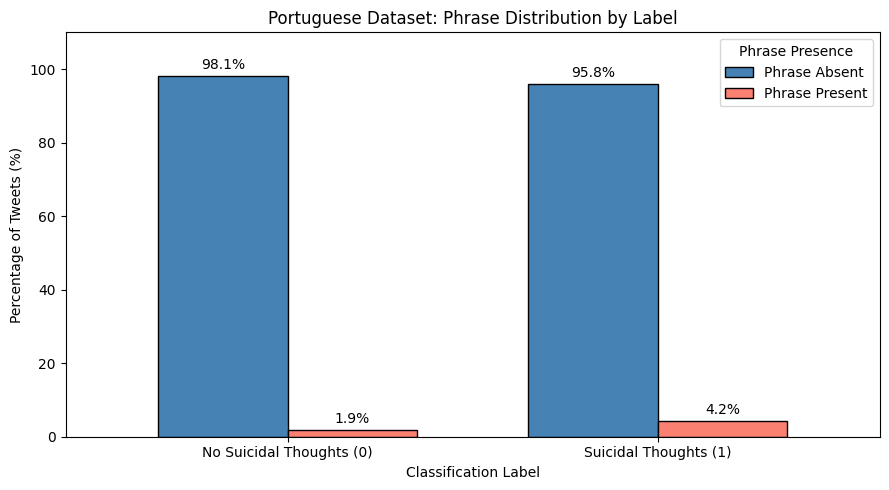

Phrase Distribution:
has_phrase  False  True 
label                   
0            1030     20
1             183      8

Phrase Distribution (%):
                          Phrase Absent  Phrase Present
No Suicidal Thoughts (0)           98.1             1.9
Suicidal Thoughts (1)              95.8             4.2


In [10]:

#Visualization 4: Portuguese Phrase Distribution by Label

#Counts phrase presence for each classification label
phrase_counts = pd.crosstab(
    df["label"],
    df["has_phrase"]
)

#Ensures both True and False categories are included
phrase_counts = phrase_counts.reindex(
    index=[0, 1],
    columns=[False, True],
    fill_value=0
)

#Calculates the percentage of tweets in each category
phrase_percentages = phrase_counts.div(
    phrase_counts.sum(axis=1), axis=0
).mul(100)

#Renames the classification labels
phrase_percentages.index = [
    "No Suicidal Thoughts (0)",
    "Suicidal Thoughts (1)"
]

#Renames the phrase categories
phrase_percentages.columns = [
    "Phrase Absent",
    "Phrase Present"
]

#Creates the grouped bar chart and assigns colours
ax = phrase_percentages.plot(
    kind="bar",
    figsize=(9, 5),
    color=["steelblue", "salmon"],
    edgecolor="black",
    width=0.7
)

#Adding labels and a title
plt.title("Portuguese Dataset: Phrase Distribution by Label")
plt.xlabel("Classification Label")
plt.ylabel("Percentage of Tweets (%)")
plt.xticks(rotation=0)
plt.legend(title="Phrase Presence")

#Displays percentages above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.ylim(0, 110)
plt.tight_layout()
plt.show()

#Displays the phrase count and percentages
print("Phrase Distribution:")
print(phrase_counts)

print("\nPhrase Distribution (%):")
print(phrase_percentages.round(1))


**Figure 4: Portuguese Phrase Distribution by Classification Label**

Figure 4 compares the presence of the identified phrase across the two classification labels in the cleaned Brazilian Portuguese dataset. The phrase appears in 8 tweets (4.2%) labelled as containing suicidal thoughts, compared to 20 tweets (1.9%) labelled as containing no suicidal thoughts. Although the negative category contains more tweets with the phrase, the percentage is higher in the positive category. Overall, the graph shows that the identified phrase is uncommon in both categories, appearing in a slightly higher percentage of tweets labelled as containing suicidal thoughts.